In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\Anton Wijaya\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "../../../data/eval_results_gemini_25_flash_lite.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [4]:
question_emb = model.encode(df["question"].tolist())
answer_emb = model.encode(df["answer"].tolist())

In [5]:
similarities = [
    cosine_similarity([q], [a])[0][0]
    for q, a in zip(question_emb, answer_emb)
]

In [6]:
df["similarity_score"] = similarities
df[["question", "answer", "similarity_score"]].head(100)

,question,answer,similarity_score
0,Laptop apa yang cocok untuk gaming budget 15 j...,Berikut adalah laptop yang cocok untuk gaming ...,0.710021
1,"Laptop ringan untuk kuliah, RAM minimal 8GB",Berikut adalah beberapa pilihan laptop ringan ...,0.538704
2,"Saya punya budget 8 juta, laptop apa yang pali...","Dengan budget 8 juta, **Asus Vivobook 14 A1404...",0.637409
3,Lebih baik pilih laptop dengan SSD 512GB atau ...,Jika Anda sering menginstal banyak aplikasi da...,0.727486
4,Laptop apa yang cocok untuk kerja kantoran ful...,"Berdasarkan informasi yang tersedia, **Laptop ...",0.592065
...,...,...,...
95,"Kalau saya punya budget 10 juta, sebaiknya pil...","Maaf, datanya belum cukup. Informasi yang dibe...",0.829487
96,Laptop apa yang cocok untuk mahasiswa teknik s...,"Berdasarkan informasi yang tersedia, **LAPTOP ...",0.659206
97,Saya ingin laptop yang enak dipakai untuk kons...,Berdasarkan informasi yang tersedia dan budget...,0.702866
98,Laptop apa yang cocok untuk developer fullstac...,"Berdasarkan informasi yang tersedia, berikut a...",0.699243


In [7]:
GROUND_TRUTH_THRESHOLD = 0.7
PREDICTION_THRESHOLD = 0.5


df["is_relevant"] = (df["similarity_score"] >= GROUND_TRUTH_THRESHOLD).astype(int)
df["predicted_relevant"] = (df["similarity_score"] >= PREDICTION_THRESHOLD).astype(int)

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df["is_relevant"], df["predicted_relevant"])
print(cm)

print(classification_report(df["is_relevant"], df["predicted_relevant"]))

[[ 4 64]
 [ 0 32]]
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        68
           1       0.33      1.00      0.50        32

    accuracy                           0.36       100
   macro avg       0.67      0.53      0.31       100
weighted avg       0.79      0.36      0.24       100



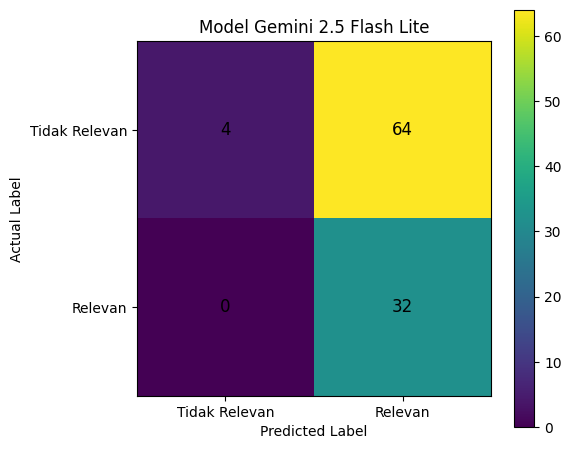

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Model Gemini 2.5 Flash Lite")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1], ["Tidak Relevan", "Relevan"])
plt.yticks([0,1], ["Tidak Relevan", "Relevan"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()